# DataSet

# ✅ Understanding Problem

Sebelum coding apa pun, pahami dulu:
- Tujuan: Memprediksi apakah besok akan hujan (RainTomorrow) → binary classification.
- Jenis fitur: kombinasi numerik (temperatur, humidity, dll.) dan kategorikal (wind direction, location, rainToday).
- Jumlah data: besar (145k rows), cukup untuk model ML modern seperti RandomForest, XGBoost, atau Logistic Regression.

# ✅ Import Library & DataSet

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\ryana\Downloads\DataSet\weatherAUS_rainfall_prediction_dataset_cleaned.csv")
pd.set_option('display.max_column', None)

In [3]:
df.sample()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
4238,2017-01-14,Albany,15.5,23.8,0.0,5.47,7.61,W,40.04,SSW,SE,13.0,18.66,62.0,51.54,1017.3,1012.7,1.0,4.51,20.8,21.68,No,No


# ✅ Exploratory Data Analysis (EDA Awal)

## 📂 Check Data Structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  object 
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  object 
 10  WindDir3pm     145460 non-null  object 
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-nul

In [5]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [6]:
df.shape

(145460, 23)

In [7]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000
mean,12.193993,23.221337,2.360898,5.468995,7.610612,40.035567,14.043384,18.662601,68.880816,51.539143,1017.649946,1015.256314,4.448437,4.509959,16.990624,21.683306
std,6.365750,7.088124,8.382488,3.161541,2.729486,13.118253,8.861059,8.716581,18.854765,20.471189,6.728467,6.663973,2.265605,2.092954,6.449221,6.850057
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000
25%,7.700000,18.000000,0.000000,4.000000,7.610000,31.000000,7.000000,13.000000,57.000000,37.000000,1013.500000,1011.100000,3.000000,4.000000,12.300000,16.700000
50%,12.100000,22.700000,0.000000,5.470000,7.610000,39.000000,13.000000,18.660000,69.000000,51.540000,1017.650000,1015.260000,4.450000,4.510000,16.800000,21.400000
75%,16.800000,28.200000,1.000000,5.470000,8.700000,46.000000,19.000000,24.000000,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.200000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000


In [8]:
df.isnull().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['RainTomorrow'].value_counts()

RainTomorrow
No     113583
Yes     31877
Name: count, dtype: int64

In [11]:
cols = df.select_dtypes('object')

for col in cols:
    print(f"Unique Value in Column{col}: ")
    print(df[col].unique())
    print()

Unique Value in ColumnDate: 
['2010-04-30' '2014-07-22' '2014-07-23' ... '2008-06-26' '2008-06-28'
 '2008-06-02']

Unique Value in ColumnLocation: 
['Adelaide' 'Albany' 'Albury' 'AliceSprings' 'BadgerysCreek' 'Ballarat'
 'Bendigo' 'Brisbane' 'Cairns' 'Canberra' 'Cobar' 'CoffsHarbour'
 'Dartmoor' 'Darwin' 'GoldCoast' 'Hobart' 'Katherine' 'Launceston'
 'Melbourne' 'MelbourneAirport' 'Mildura' 'Moree' 'MountGambier'
 'MountGinini' 'Newcastle' 'Nhil' 'NorahHead' 'NorfolkIsland' 'Nuriootpa'
 'PearceRAAF' 'Penrith' 'Perth' 'PerthAirport' 'Portland' 'Richmond'
 'Sale' 'SalmonGums' 'Sydney' 'SydneyAirport' 'Townsville' 'Tuggeranong'
 'Uluru' 'WaggaWagga' 'Walpole' 'Watsonia' 'Williamtown' 'Witchcliffe'
 'Wollongong' 'Woomera']

Unique Value in ColumnWindGustDir: 
['ENE' 'N' 'NE' 'NNE' 'NW' 'NNW' 'W' 'WSW' 'S' 'SSW' 'SW' 'WNW' 'SSE' 'SE'
 'E' 'ESE']

Unique Value in ColumnWindDir9am: 
['ENE' 'N' 'NNE' 'NW' 'WNW' 'NNW' 'NE' 'SW' 'SE' 'WSW' 'SSW' 'S' 'ESE' 'E'
 'W' 'SSE']

Unique Value in ColumnW

## ⚠️ Check Imbalance Class

<Figure size 600x400 with 0 Axes>

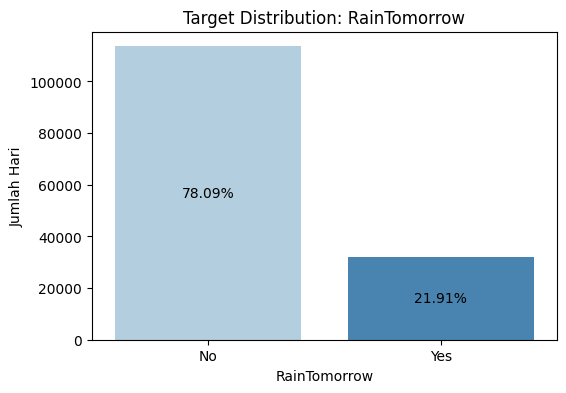

In [12]:
# --- 1. Distribusi Target: RainTomorrow ---
plt.figure(figsize=(6,4))
plt.figure(figsize=(6,4))
ax = sns.countplot(x='RainTomorrow', data=df, hue='RainTomorrow', palette='Blues', legend=False)

plt.title('Target Distribution: RainTomorrow', fontsize=12)
plt.xlabel('RainTomorrow')
plt.ylabel('Jumlah Hari')

# Tambahkan label persentase di tengah batang
total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height/2,   # di tengah batang
            f"{height/total*100:.2f}%", 
            ha='center', va='center', color='black', fontsize=10)

plt.show()

## ⚠️ Check Anomali Value

### ⭐ Check 1 — RainToday = "Yes" but Rainfall = 0
Secara logika:
- Jika RainToday = "Yes" → harusnya ada hujan (Rainfall > 0)

In [13]:
anom_1 = df[(df['RainToday'] == 'Yes') & (df['Rainfall'] == 0)]
print(f"Anomali 1 : RainToday == 'Yes' but 'Rainfall' == 0 ")
print(anom_1.head())
print("Total Anomali: ", len(anom_1))

Anomali 1 : RainToday == 'Yes' but 'Rainfall' == 0 
Empty DataFrame
Columns: [Date, Location, MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustDir, WindGustSpeed, WindDir9am, WindDir3pm, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am, Temp3pm, RainToday, RainTomorrow]
Index: []
Total Anomali:  0


### ⭐ Check 2 — Pressure di luar batas wajar
Tekanan udara normal biasanya:
- 980–1050 hPa
- (Nilai < 800 atau > 1100 hampir pasti salah)

In [14]:
anom_2 = df[(df['Pressure9am'] < 800) | (df['Pressure9am'] > 1100) |
            (df['Pressure3pm'] < 800) | (df['Pressure3pm'] > 1100)]

print("Anomali 2: Tekanan udara di luar batas wajar")
print(anom_2.head())
print("Jumlah anomali:", len(anom_2))

Anomali 2: Tekanan udara di luar batas wajar
Empty DataFrame
Columns: [Date, Location, MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustDir, WindGustSpeed, WindDir9am, WindDir3pm, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am, Temp3pm, RainToday, RainTomorrow]
Index: []
Jumlah anomali: 0


### ⭐ Check 3 — WindGustSpeed = 0 but WindGustDir =! 0
Kecepatan angin = 0 berarti angin mati total, jadi arah tidak logis.

In [15]:
anom_3 = df[(df['WindGustSpeed'] == 0) & (df['WindGustDir'].notna())]
print("Anomali 3: WindGustSpeed=0 tapi ada WindGustDir")
print(anom_3.head())
print("Jumlah anomali:", len(anom_3))

Anomali 3: WindGustSpeed=0 tapi ada WindGustDir
Empty DataFrame
Columns: [Date, Location, MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustDir, WindGustSpeed, WindDir9am, WindDir3pm, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am, Temp3pm, RainToday, RainTomorrow]
Index: []
Jumlah anomali: 0


### ⭐ Check 4 — WindSpeed9am/3pm = 0 tetapi ada arah angin

In [16]:
anom_4 = df[(df['WindSpeed9am'] == 0) & (df['WindDir9am'].notna())]
anom_5 = df[(df['WindSpeed3pm'] == 0) & (df['WindDir3pm'].notna())]

print("Anomali 4: WindSpeed9am=0 tapi ada arah angin")
print(anom_4.head())

Anomali 4: WindSpeed9am=0 tapi ada arah angin
          Date  Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
1   2014-07-22  Adelaide      3.7     19.0       0.0         1.40      7.61   
14  2014-08-04  Adelaide      0.9     14.6       0.0         4.40      7.61   
15  2014-08-05  Adelaide      3.0     16.9       0.0         1.20      7.61   
16  2014-08-06  Adelaide      3.3     16.1       0.0         1.60      7.61   
22  2014-07-20  Adelaide      4.7     14.5       0.0         5.47      7.61   

   WindGustDir  WindGustSpeed WindDir9am WindDir3pm  WindSpeed9am  \
1            N           24.0          N        NNE           0.0   
14           W           24.0          N          W           0.0   
15         WSW           20.0          N        WSW           0.0   
16         WSW           22.0          N        WSW           0.0   
22           N           24.0          N        NNE           0.0   

    WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressur

In [17]:
print("Anomali 5: WindSpeed3pm=0 tapi ada arah angin")
print(anom_5.head())

Anomali 5: WindSpeed3pm=0 tapi ada arah angin
            Date  Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
729   2013-09-05  Adelaide     15.6     15.9      0.20         3.40      0.00   
766   2013-12-01  Adelaide     16.5     27.2      2.36         5.47      2.40   
930   2016-06-02  Adelaide      9.6     19.0      0.20         5.47      7.61   
1077  2017-05-15  Adelaide      6.8     22.5      0.00         5.47      7.61   
1094  2017-06-02  Adelaide      2.5     17.2      0.00         5.47      7.61   

     WindGustDir  WindGustSpeed WindDir9am WindDir3pm  WindSpeed9am  \
729           SW           24.0        SSW         SE           9.0   
766           NE           50.0          N         SE           9.0   
930          NNE           20.0         NE         SE           4.0   
1077         ENE           20.0          N         SE           0.0   
1094         NNE           20.0         NW         SE           2.0   

      WindSpeed3pm  Humidity9am  Humidit

### ⭐ Check 5 — Cloud oktas di luar range (0–8)
Oktas (unit cloud cover) hanya valid antara 0–8.

In [18]:
anom_6 = df[(df['Cloud9am'] < 0) | (df['Cloud9am'] > 8) |
            (df['Cloud3pm'] < 0) | (df['Cloud3pm'] > 8)]

print("Anomali 6: Cloud cover di luar rentang 0–8")
print(anom_6.head())
print("Jumlah anomali:", len(anom_6))

Anomali 6: Cloud cover di luar rentang 0–8
              Date  Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
28721   2012-05-27  Canberra      0.6     14.5       0.0         5.47   
112190  2009-09-23    Sydney     17.0     21.8       4.4        11.20   
144795  2012-11-02   Woomera     10.6     24.6       0.2        11.60   

        Sunshine WindGustDir  WindGustSpeed WindDir9am WindDir3pm  \
28721        7.8          SW          30.00        NNW        SSW   
112190       8.0           W          40.04          W          W   
144795      11.4         SSE          39.00         SE        ESE   

        WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  \
28721            4.0           9.0         99.0         41.0       1022.4   
112190          30.0          37.0         40.0         36.0        996.8   
144795          26.0          17.0         45.0         13.0       1019.0   

        Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm RainToday  \
28721  

### ⭐ Check 6 — Temperatur tidak masuk akal
Temperatur normal bumi → -20 hingga 55 derajat C  
Di luar ini = kemungkinan noise/error.

In [19]:
anom_7 = df[(df['MinTemp'] < -20) | (df['MinTemp'] > 50) |
            (df['MaxTemp'] < -20) | (df['MaxTemp'] > 55)]

In [20]:
print("Anomali 7: Temperature tidak realistis")
print(anom_7.head())
print("Jumlah anomali:", len(anom_7))

Anomali 7: Temperature tidak realistis
Empty DataFrame
Columns: [Date, Location, MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustDir, WindGustSpeed, WindDir9am, WindDir3pm, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am, Temp3pm, RainToday, RainTomorrow]
Index: []
Jumlah anomali: 0


### ⭐ Check 7 — Humidity harus 0–100%

In [21]:
anom_8 = df[(df['Humidity9am'] < 0) | (df['Humidity9am'] > 100) |
            (df['Humidity3pm'] < 0) | (df['Humidity3pm'] > 100)]

print("Anomali 8: Humidity di luar rentang 0–100")
print(anom_8.head())
print("Jumlah anomali:", len(anom_8))

Anomali 8: Humidity di luar rentang 0–100
Empty DataFrame
Columns: [Date, Location, MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustDir, WindGustSpeed, WindDir9am, WindDir3pm, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am, Temp3pm, RainToday, RainTomorrow]
Index: []
Jumlah anomali: 0


### ⭐ Check 8 — Evaporation negatif (tidak mungkin)

In [22]:
anom_9 = df[df['Evaporation'] < 0]
print("Anomali 9: Evaporation negatif")
print(anom_9.head())
print("Jumlah anomali:", len(anom_9))

Anomali 9: Evaporation negatif
Empty DataFrame
Columns: [Date, Location, MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustDir, WindGustSpeed, WindDir9am, WindDir3pm, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am, Temp3pm, RainToday, RainTomorrow]
Index: []
Jumlah anomali: 0


## 🎯 Summary for Anomali Value

In [23]:
anomaly_summary = {
    "RainToday=Yes but Rainfall=0": len(anom_1),
    "Pressure out of range": len(anom_2),
    "WindGustSpeed=0 but has direction": len(anom_3),
    "WindSpeed9am=0 but direction exists": len(anom_4),
    "WindSpeed3pm=0 but direction exists": len(anom_5),
    "Cloud oktas out of range": len(anom_6),
    "Temperature unrealistic": len(anom_7),
    "Humidity out of range": len(anom_8),
    "Evaporation negative": len(anom_9),
}

anomaly_summary

{'RainToday=Yes but Rainfall=0': 0,
 'Pressure out of range': 0,
 'WindGustSpeed=0 but has direction': 0,
 'WindSpeed9am=0 but direction exists': 8745,
 'WindSpeed3pm=0 but direction exists': 1112,
 'Cloud oktas out of range': 3,
 'Temperature unrealistic': 0,
 'Humidity out of range': 0,
 'Evaporation negative': 0}

# ✅ Data Cleaning

# ✅ Feature Engineering

## Konversi Data Type

In [24]:
df['Date'] = pd.to_datetime(df['Date'])

## Extract fitur waktu

In [25]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df.drop(columns=['Date'], inplace=True)
df.drop(columns=['Location'], inplace=True)

In [26]:
df.sample()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
67248,1.0,14.4,0.0,0.8,5.2,SE,19.0,N,NNE,0.0,7.0,97.0,61.0,1023.6,1021.9,6.0,4.0,4.9,14.2,No,No,2011,8,13


## Encode Feature Target

In [27]:
df['RainTomorrow'] = df['RainTomorrow'].map({'No':0, 'Yes':1})
df['RainToday'] = df['RainToday'].map({'No':0, 'Yes':1})

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   MinTemp        145460 non-null  float64
 1   MaxTemp        145460 non-null  float64
 2   Rainfall       145460 non-null  float64
 3   Evaporation    145460 non-null  float64
 4   Sunshine       145460 non-null  float64
 5   WindGustDir    145460 non-null  object 
 6   WindGustSpeed  145460 non-null  float64
 7   WindDir9am     145460 non-null  object 
 8   WindDir3pm     145460 non-null  object 
 9   WindSpeed9am   145460 non-null  float64
 10  WindSpeed3pm   145460 non-null  float64
 11  Humidity9am    145460 non-null  float64
 12  Humidity3pm    145460 non-null  float64
 13  Pressure9am    145460 non-null  float64
 14  Pressure3pm    145460 non-null  float64
 15  Cloud9am       145460 non-null  float64
 16  Cloud3pm       145460 non-null  float64
 17  Temp9am        145460 non-nul

## Encode Categorical Column

In [29]:
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack
import numpy as np

In [30]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [31]:
cat_cols

['WindGustDir', 'WindDir9am', 'WindDir3pm']

In [32]:
# 2. Pisahkan X dan y
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

In [33]:
# 3. OneHotEncoder untuk kolom kategorikal
encoder = OneHotEncoder(handle_unknown='ignore')
X_cat_encoded = encoder.fit_transform(X[cat_cols])

In [34]:
# 4. Ambil fitur numerik
num_cols = X.drop(columns=cat_cols).columns.tolist()
X_num = X[num_cols].values  # dalam bentuk array

In [35]:
# 5. Gabungkan kategori + numerik
X_encoded = hstack([X_cat_encoded, X_num])

# 🤖 Machine Learning

## Split Data Train/Test

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

#✅ stratify=y penting agar kelas minoritas tetap terwakili di train & test.

In [38]:
print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (116368, 68) (116368,)
Test set: (29092, 68) (29092,)


## 🎯 Imbalance Handling
Ada beberapa cara populer:
- Class weight (langsung di model, misal RandomForest, XGBoost)
- Resampling: Oversampling (SMOTE) atau undersampling

### ✅ SMOTE (oversampling kelas minoritas)

In [39]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

In [40]:
#penerapan SMOTE ke data Train saja

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [41]:
print("Sebelum SMOTE:", y_train.value_counts())
print("Sesudah SMOTE:", y_train_res.value_counts())

Sebelum SMOTE: RainTomorrow
0    90866
1    25502
Name: count, dtype: int64
Sesudah SMOTE: RainTomorrow
0    90866
1    90866
Name: count, dtype: int64


Penjelasan:
- X_train_res → fitur train setelah oversampling
- y_train_res → target train setelah oversampling
- Test set tidak diubah, tetap asli agar evaluasi valid

## 🥽 Modelling 

### 🎯 1. Model Baseline: RandomForest

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [43]:
# Create Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
)

In [44]:
# Training
rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [45]:
# prediction
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:,1] # probabilitas untuk ROC-AUC

In [46]:
# Evaluasi
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
 [[21213  1504]
 [ 2865  3510]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91     22717
           1       0.70      0.55      0.62      6375

    accuracy                           0.85     29092
   macro avg       0.79      0.74      0.76     29092
weighted avg       0.84      0.85      0.84     29092

ROC-AUC Score: 0.8793981150852734


✅ Penjelasan:
- class_weight='balanced' → membantu model fokus pada kelas minoritas
- classification_report → melihat precision, recall, F1-score
- roc_auc_score → metrik penting untuk dataset imbalance

### 🎯 2. Model Baseline: Logistic Regression

In [47]:
from sklearn.linear_model import LogisticRegression

In [49]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler(with_mean=False)
# X_train_scaled = scaler.fit_transform(X_train_res)
# X_test_scaled = scaler.transform(X_test)

In [54]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()
X_train_scaled = normalizer.fit_transform(X_train_res)
X_test_scaled = normalizer.transform(X_test)

In [63]:
# lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
# lr_model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

lr_model = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=5000,
    random_state=42
)

In [64]:
# Training
# lr_model.fit(X_train_res, y_train_res)
lr_model.fit(X_train_scaled, y_train_res)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42,
                   solver='liblinear')

In [65]:
# prediction
y_pred = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)[:,1] # probabilitas untuk ROC-AUC

In [66]:
# Evaluasi
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
 [[18655  4062]
 [ 2032  4343]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.82      0.86     22717
           1       0.52      0.68      0.59      6375

    accuracy                           0.79     29092
   macro avg       0.71      0.75      0.72     29092
weighted avg       0.82      0.79      0.80     29092

ROC-AUC Score: 0.7799537808344275


In [ ]:
#XgBoost
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_estimators=100
)